In [4]:
import os
import glob
import sys


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb  # Has to be imported first to avoid conflicts with PyROOT
import json
from time import time
from datetime import timedelta
from yaml import safe_load, YAMLError, dump
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc
from xgboost import XGBClassifier

import config as cfg
import efficiency_finder
#import variable_plotter as vp
plt.style.use('fcc.mplstyle')

def set_outputpath(outputpath):
    if not os.path.exists(outputpath):
        os.makedirs(outputpath)
    return outputpath

# Function to load the BDT model from a JSON file
def load_bdt_model(json_path):
    bdt_model = xgb.Booster()
    bdt_model.load_model(json_path)
    return bdt_model

# Function to load the BDT model from a JSON file
def load_bdt_model_sklearn(json_path):
    bdt_model = XGBClassifier()
    bdt_model.load_model(json_path)
    return bdt_model

# Return list of variables to use in the bdt as a python list
def vars_fromyaml(path, bdtlist):
    with open(path) as stream:
        try:
            file = safe_load(stream)
            bdtvars = file[bdtlist]
        except YAMLError as exc:
            print(exc)
    return bdtvars

def load_bdt_and_apply(pickled_df_fname = "bdt_lh_full_dataframe.pkl", # once have put ALL data into a df
                        config_bdtopts = cfg.optimised_bdt_lh_opts,
                        bdtname = 'BDT_lh_default_hps_bdtlh-vars-v1',
                        training_round = "multiclass_hp_opt_v1", #to change if change multiclass
                        features_list_name = "bdtlh-vars-v1",
                        bdt_label = '_lh',
                        ): # hps dict and features_list_name specift BDT used
    

    #path to data and outputs
    outputpath   = config_bdtopts['outputPath']
    yamlpath = cfg.fccana_opts['yamlPath']

    #Getting BDT vars for training from yaml
    bdtvars      = vars_fromyaml(yamlpath, features_list_name)


    #path to pickled data
    pickled_df_path = os.path.join(outputpath, pickled_df_fname)

    #path to saved bdt
    bdt_json_path = os.path.join(outputpath,training_round,f"{bdtname}.json")

    # Load the BDT model
    try:
        print("Loading BDT model...")
        bdt_model = load_bdt_model_sklearn(bdt_json_path)
        print("BDT model loaded successfully.")
    except Exception as e:
        print(f"Error loading BDT model: {e}")
        quit()

    # Read df saved to pickle and add BDT 

    #Getting BDT vars for training from yaml
    # load pickled df
    df = pd.read_pickle(pickled_df_path)

    #add bdt score
    class_names = bdt_model.classes_
    probabilities = bdt_model.predict_proba(df[bdtvars])
    for i in range(probabilities.shape[1]):
        df[f'bdt_score_{class_names[i]}'] = probabilities[:, i]

    return bdt_model, bdtname, df




In [26]:
def multi_bdt_cut_opt_PlPh(df, lsearch = 1- np.linspace(0.00005,0.00501,100), hsearch = 1- np.linspace(0.00005,0.00501,100), outputpath = None, plotname = 'muliclass_2d_cut_opt_3sigmaBF', rootfilespath = cfg.optimised_bdt_lh_opts["inputPath"]):
    
    eff_dict={}
    eff_df=np.zeros((len(lsearch), len(hsearch)))
    for decay in df["decay"].unique():
        eff_df=np.zeros((len(lsearch), len(hsearch)))
        subf = df[df["decay"]==decay]
        l_arr=[]
        h_arr=[]

        for l in np.arange(0,len(lsearch),1):
            for h in np.arange(0,len(hsearch),1):
                l_arr.append(lsearch[l])
                h_arr.append(hsearch[h])

                cutdf = subf[((1-subf["bdt_score_1"])>hsearch[h])&((1-subf["bdt_score_0"])>lsearch[l])]
                eff_lh = len(cutdf)/len(subf)
                eff_df[l][h] = eff_lh

        eff_dict[f"{decay}"] = eff_df
    

    bf_arr = np.zeros((len(lsearch), len(hsearch)))
    B_arr = np.zeros((len(lsearch), len(hsearch)))
    B_eff_arr = np.zeros((len(lsearch), len(hsearch)))
    sig_eff_arr_cut = np.zeros((len(lsearch), len(hsearch)))
    bf_B0_arr = np.zeros((len(lsearch), len(hsearch)))


    #approximate prelim cut eff
    '''
    prelim_eff = {"p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu": 0.876, 
        "p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu": 0.884,  
        "p8_ee_Zbb_ecm91": 0.058,
        "p8_ee_Zcc_ecm91": 0.042,
        "p8_ee_Zss_ecm91": 0.046,
        "p8_ee_Zud_ecm91": 0.024,
    }
    '''


    eff_arr =  efficiency_finder.get_efficiencies('custom',
                                                        further_analysis=True,
                                                        samples = cfg.sample_allocations["hadronic_background"]+cfg.sample_allocations["combined_signal"],
                                                        raw=True, #ie. want full efficiency including tupling and prelim cuts
                                                        custompath=rootfilespath,
                                                        verbose=False)

    prelim_eff = {key: value for key, value in eff_arr.items() if key.endswith('_eff')}

                                                                                                                                                                                        
    k = 2* cfg.prod_frac["Bs"] * cfg.branching_fractions["p8_ee_Zbb_ecm91"][0]*cfg.N_z*prelim_eff["p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu_eff"]

    sig_eff= eff_dict['p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu']

    l_elements = sorted(list(set(l_arr)))
    h_elements = sorted(list(set(h_arr)))


    for l in np.arange(0,len(l_elements), 1):
        for h in np.arange(0,len(h_elements), 1): 
            #3sigma bf for Bs so that comparable to old work
            K = k * sig_eff[l,h]
            sig_eff_arr_cut[l,h] = K
            B = sum([cfg.branching_fractions[s][0]*cfg.N_z*prelim_eff[f'{s}_eff']* eff_dict[s][l,h] for s in cfg.sample_allocations["hadronic_background"]])
            B_nocut = sum([cfg.branching_fractions[s][0]*cfg.N_z*prelim_eff[f'{s}_eff'] for s in cfg.sample_allocations["hadronic_background"]])
            bf =1/(2*K)*(9+np.sqrt(81+36*B))
            bf_arr[l,h]=bf
            B_arr[l,h]=B
            B_eff_arr[l,h]=B/B_nocut
            bf_B0_arr[l,h] = 9/K

    ############################################
    #save optimum point to log file
    ############################################

    # Write key info to log file
    if outputpath:
        with open(os.path.join(outputpath,f'{plotname}.log'), 'a') as log_file:
            log_file.write(f'Minimum BF at naive 3 sigma: {np.min(bf_arr)}')
            log_file.write(f'Total hadronic B at this cut= {B_arr[np.where(bf_arr == np.min(bf_arr))]}')
            log_file.write(f'signal eff at this cut= {sig_eff_arr_cut[np.where(bf_arr == np.min(bf_arr))]}')
            log_file.write(f'Minimum BF at naive 3 sigma if B==0: {bf_B0_arr[np.where(bf_arr == np.min(bf_arr))]}')
            log_file.write(f'cut on 1-P(light) > {l_elements[np.where(bf_arr == np.min(bf_arr))[0][0]]}')
            log_file.write(f'cut on 1-P(heavy) > {h_elements[np.where(bf_arr == np.min(bf_arr))[1][0]]}')
    
    else:
        with open(f'{plotname}.log', 'a') as log_file:
            log_file.write(f'Minimum BF at naive 3 sigma: {np.min(bf_arr)}')
            log_file.write(f'Total hadronic B at this cut= {B_arr[np.where(bf_arr == np.min(bf_arr))]}')
            log_file.write(f'signal eff at this cut= {sig_eff_arr_cut[np.where(bf_arr == np.min(bf_arr))]}')
            log_file.write(f'Minimum BF at naive 3 sigma if B==0: {bf_B0_arr[np.where(bf_arr == np.min(bf_arr))]}')
            log_file.write(f'cut on 1-P(light) > {l_elements[np.where(bf_arr == np.min(bf_arr))[0][0]]}')
            log_file.write(f'cut on 1-P(heavy) > {h_elements[np.where(bf_arr == np.min(bf_arr))[1][0]]}')


    # sensitivity all stored in bf_arr = bf you would on average expect to see at 3 sigma
    print(f'Minimum BF at naive 3 sigma: {np.min(bf_arr)}')
    print(f'Total hadronic B at this cut= {B_arr[np.where(bf_arr == np.min(bf_arr))]}')
    print(f'signal eff at this cut= {sig_eff_arr_cut[np.where(bf_arr == np.min(bf_arr))]}')
    print(f'Minimum BF at naive 3 sigma if B==0: {bf_B0_arr[np.where(bf_arr == np.min(bf_arr))]}')
    print(f'cut on 1-P(light) > {l_elements[np.where(bf_arr == np.min(bf_arr))[0][0]]}')
    print(f'cut on 1-P(heavy) > {h_elements[np.where(bf_arr == np.min(bf_arr))[1][0]]}')
    print('-----------------------------------------------------------------')



    ##############################################
    # produce plots
    ##############################################

    plt.figure()
    plt.imshow(bf_arr, origin='lower',vmax=1.8e-7)
    plt.xlabel('BDT_lh 1-P(heavy)')
    plt.ylabel('BDT_lh 1-P(light)')
    plt.colorbar(label='BF limit at 3 sigma')

    # Set tick labels for every 10th bin
    ytick_indices = np.arange(0,len(l_elements), round(len(l_elements)/5))
    xtick_indices = np.arange(0, len(h_elements), round(len(h_elements)/5))

    # Use ytick_indices and xtick_indices to set the ticks
    plt.yticks(ytick_indices, [round(l_elements[i],5) for i in ytick_indices])
    plt.xticks(xtick_indices, [round(h_elements[i],5) for i in xtick_indices], rotation=90)
    plt.show()
    if outputpath:
        plt.savefig(os.path.join(outputpath,f'{plotname}.pdf'))
    else:
        plt.savefig(f'{plotname}.pdf')
    


    # plot slices
    h = h_elements[np.where(bf_arr == np.min(bf_arr))[1][0]]
    l = l_elements[np.where(bf_arr == np.min(bf_arr))[0][0]]

    #slice at cionstant l
    plt.plot(bf_arr[l,:])
    h_elements = sorted(list(set(h_arr)))

    # Set tick labels for every 10th bin
    xtick_indices = np.arange(0, len(h_elements), round(len(h_elements)/5))

    # Use ytick_indices and xtick_indices to set the ticks
    plt.xticks(xtick_indices, [round(h_elements[i],5) for i in xtick_indices], rotation=90)
    plt.xlabel(r'P(h) cut for 1-P(l)$>$'+f'{round(l_elements[l],6)}')
    plt.ylabel(f'Bs BF at naive 3 sigma')
    plt.show()
    if outputpath:
        plt.savefig(os.path.join(outputpath,f'{plotname}_hslice.pdf'))
    else:
        plt.savefig(f'{plotname}_hslice.pdf')

    #slice at constant h
    plt.plot(bf_arr[:,h])
    l_elements = sorted(list(set(l_arr)))

    # Set tick labels for every 10th bin
    xtick_indices = np.arange(0, len(l_elements), round(len(l_elements)/5))

    # Use ytick_indices and xtick_indices to set the ticks
    plt.xticks(xtick_indices, [round(l_elements[i],5) for i in xtick_indices], rotation=90)
    plt.xlabel(r'P(l) cut for 1-P(h)$>$'+f'{round(h_elements[h],6)}')
    plt.ylabel(f'Bs BF at naive 3 sigma')
    plt.show()
    if outputpath:
        plt.savefig(os.path.join(outputpath,f'{plotname}_lslice.pdf'))
    else:
        plt.savefig(f'{plotname}_lslice.pdf')


        
    return bf_arr

Loading BDT model...
BDT model loaded successfully.
/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/full_prelim_cuts_500k/bdt_lh_outputs/multiclass_baseline/bdt_cut_optimisation
Minimum BF at naive 3 sigma: 2.676408278931588e-09
Total hadronic B at this cut= [0.]
signal eff at this cut= [3.36271565e+09]
Minimum BF at naive 3 sigma if B==0: [2.67640828e-09]
cut on 1-P(light) > 0.99499
cut on 1-P(heavy) > 0.995040101010101
-----------------------------------------------------------------


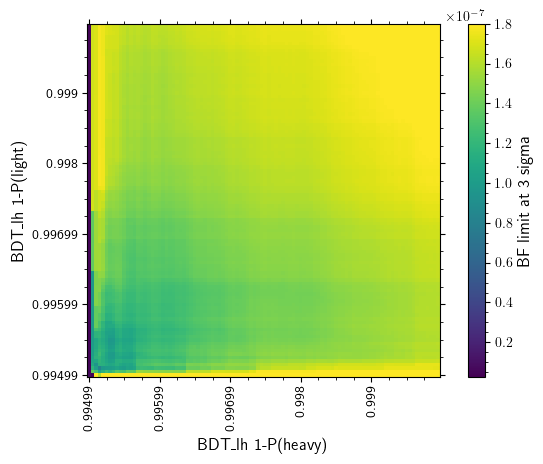

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

<Figure size 640x480 with 0 Axes>

In [27]:
model, bdtname, dataframe = load_bdt_and_apply(pickled_df_fname = "bdt_lh_dataframe.pkl", 
                        config_bdtopts = cfg.bdt_lh_opts,
                        bdtname = 'BDT_lh_default-hps_bdth-plus-vars',
                        training_round = "multiclass_baseline", #to change if change multiclass
                        features_list_name = "bdth-plus-vars",
                        bdt_label = '_lh',
                        )

outputpath = set_outputpath(os.path.join(cfg.bdt_lh_opts['outputPath'],"multiclass_baseline","bdt_cut_optimisation"))
print(outputpath)
multi_bdt_cut_opt_PlPh(dataframe, outputpath = outputpath, rootfilespath = cfg.bdt_lh_opts["inputPath"])
    
